In [23]:
import gymnasium as gym

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from libraries import fdrl26_fl as fl
from libraries import fdrl26_rl as rl

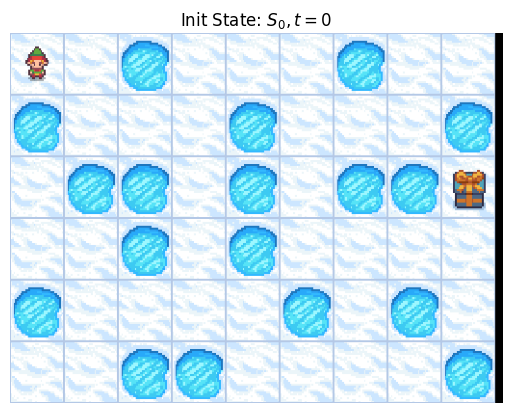

In [24]:
map = [
    "SFHFFFHFF",
    "HFFFHFFFH",
    "FHHFHFHHG",
    "FFHFHFFFF",
    "HFFFFHFHF",
    "FFHHFFFFH"
]

env = gym.make(
    "FrozenLake-v1",
    is_slippery = True,
    desc = map,
    max_episode_steps=400,
    render_mode="rgb_array"
)

nS = env.observation_space.n
nA = env.action_space.n
action_symbols = {0: 'L', 1: 'D', 2: 'R', 3: 'U'}
action_arrows  = {0: '←', 1: '↓', 2: '→', 3: '↑'}

N = len(map)

state, info = env.reset()
pic=env.render()
plt.imshow(pic)
plt.title("Init State: $S_0,  t=0$")
plt.axis('off')

plt.savefig("./data/FL_initstate.png", bbox_inches="tight")

plt.show()

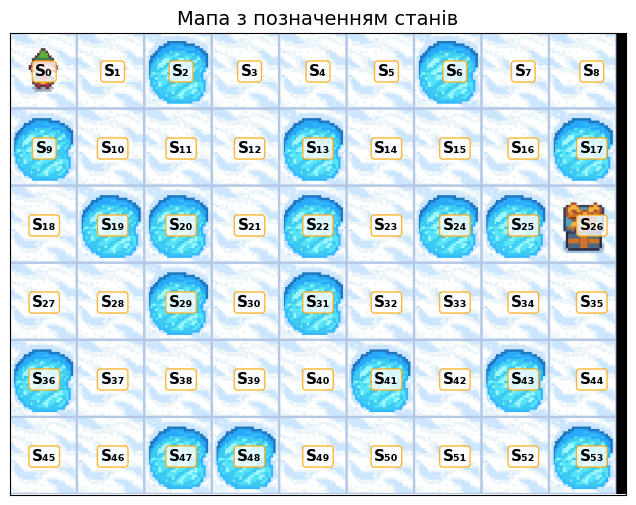

In [25]:
def to_subscript(n):
    sub_digits = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    return str(n).translate(sub_digits)

img = env.render()
rows, cols = len(map), len(map[0])

plt.figure(figsize=(10, 6))
plt.imshow(img)

plt.xticks([])
plt.yticks([])

height, width, _ = img.shape
cell_h = height / rows
cell_w = width / cols

for r in range(rows):
    for c in range(cols):
        state_idx = r * cols + c
        x = (c + 0.5) * cell_w
        y = (r + 0.5) * cell_h
        state_str = f"S{to_subscript(state_idx)}"
        
        plt.text(x, y, state_str, color='black', fontsize=11, 
                 fontweight='bold', ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='orange'))

plt.xlim(0, width)
plt.ylim(height, 0)

plt.title(f"Мапа з позначенням станів", fontsize=14)
plt.show()